# 1- Environnement & Config 

In [4]:
# ============================================================
# STEP 1 — Environnement & Config
# Baseline Standard CE  /  QMix  (DDR uniquement)
# Fidèle au papier : ResNet50, ImageNet, 384×384, bs=16,
# lr=1e-3, 100 époques, warmup=10, τ=0.07, λm=1
# ============================================================
import os, math, time, csv, random
from pathlib import Path
from collections import defaultdict
!pip install codecarbon
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score
import yaml

# — Hardware —
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"GPUs    : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i} : {torch.cuda.get_device_name(i)} "
          f"— {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

# ── Config (fidèle au papier Section IV-B) ───────────────────
class Cfg:
    # ── Dataset ──────────────────────────────────────────────
    data_dir   = '/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset'
    n_class    = 5           # DR grades 0–4  (classe 5 = ungradable exclue)
    img_size   = 896        # papier : 384×384
    n_worker   = 4
    pin_memory = True
    seed       = 42

    # ── Tâche & métriques ────────────────────────────────────
    # Papier : évaluation par Quadratic Weighted Kappa (QWK), Table II & III
    # On suit exactement les métriques reportées dans le papier
    task = {
        'name'   : 'dr_grade',
        'act_fn' : 'softmax',          # sortie softmax → NLLLoss
        'metrics': ['kappa', 'accuracy', 'f1'],
        # Référence papier (Table II, 50% Mis-H + 15% Mis-L, symétrique) :
        #   Standard CE  → Best=81.4 / Last=39.7   (kappa %)
        #   QMix         → Best=87.9 / Last=86.3   (kappa %)
        # Sans bruit (Table II col 0% noise proxy / Fig.2) :
        #   Standard CE  → ~88.3  (kappa %)
        #   QMix         → ~90.1  (kappa %)
        'paper_reference': {
            'standard_ce': {
                'no_noise'      : {'kappa_best': 88.3},
                '50MisH_15MisL' : {'kappa_best': 81.4, 'kappa_last': 39.7},
                '80MisH_15MisL' : {'kappa_best': 72.4, 'kappa_last': 15.9},
            },
            'qmix': {
                'no_noise'      : {'kappa_best': 90.1},
                '50MisH_15MisL' : {'kappa_best': 87.9, 'kappa_last': 86.3},
                '80MisH_15MisL' : {'kappa_best': 81.2, 'kappa_last': 75.9},
            },
        },
    }

    # ── Entraînement ─────────────────────────────────────────
    n_epoch        = 50     # papier : 100 epochs
    n_epoch_warmup = 10      # papier : 10 warmup epochs (CE pur avant QMix)
    batch_size     = 16      # papier : batch size 16
    lr             = 1e-3    # papier : lr = 1e-3
    wd             = 1e-4
    eps            = 1e-6

    # ── QMix spécifique ──────────────────────────────────────
    tau      = 0.07          # papier : τ = 0.07  (contrastive temperature)
    lambda_m = 1.0           # papier : λm = 1    (poids MSE Mis-H)
    lambda_c = 1.0           # λc  (poids contrastive, ablation Table IV)
    dp       = 128           # dim projection contrastive (MLP 2 couches)
    M_aug    = 2             # papier : M=2 augmentations faibles par sample
    omega_0  = 0.5           # Ω(0) : poids initial Mis-L dans sample-reweighing

    # ── Noise synthétique DDR ────────────────────────────────
    # Paramétrable pour reproduire toutes les colonnes de Table II
    # Défaut : condition principale du papier
    noise_type  = 'symmetric'   # 'symmetric' | 'asymmetric'
    mis_h_ratio = 0.50          # 50% Mis-H
    mis_l_ratio = 0.15          # 15% Mis-L

    # ── Encodeur (papier Section IV-B) ───────────────────────
    enc_type   = 'resnet50'     # papier : ResNet-50
    pretrained = True           # papier : pré-entraîné ImageNet

    # ── Suivi efficacité (VRAM + temps) ──────────────────────
    track_epochs = [0, 1]       # époques instrumentées comme dans ta structure

cfg = Cfg()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)

# ── Affichage récap ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"Config chargée ✓")
print(f"  Tâche      : {cfg.task['name']}  ({cfg.n_class} classes)")
print(f"  Métriques  : {cfg.task['metrics']}")
print(f"  img_size   : {cfg.img_size}×{cfg.img_size}")
print(f"  n_epoch    : {cfg.n_epoch}  (warmup={cfg.n_epoch_warmup})")
print(f"  batch_size : {cfg.batch_size}  |  lr={cfg.lr}  |  wd={cfg.wd}")
print(f"  Encodeur   : {cfg.enc_type}  pretrained={cfg.pretrained}")
print(f"  Noise      : {cfg.noise_type}  "
      f"Mis-H={cfg.mis_h_ratio*100:.0f}%  Mis-L={cfg.mis_l_ratio*100:.0f}%")
print(f"\n── Références papier (kappa %) ──")
ref = cfg.task['paper_reference']
print(f"  Standard CE │ no_noise={ref['standard_ce']['no_noise']['kappa_best']}  "
      f"│ 50H+15L Best={ref['standard_ce']['50MisH_15MisL']['kappa_best']} "
      f"Last={ref['standard_ce']['50MisH_15MisL']['kappa_last']}")
print(f"  QMix        │ no_noise={ref['qmix']['no_noise']['kappa_best']}  "
      f"│ 50H+15L Best={ref['qmix']['50MisH_15MisL']['kappa_best']} "
      f"Last={ref['qmix']['50MisH_15MisL']['kappa_last']}")
print(f"{'='*55}")

Device  : cuda
GPUs    : 2
  GPU 0 : Tesla T4 — 15.6 GB
  GPU 1 : Tesla T4 — 15.6 GB
PyTorch : 2.10.0+cu128

Config chargée ✓
  Tâche      : dr_grade  (5 classes)
  Métriques  : ['kappa', 'accuracy', 'f1']
  img_size   : 384×384
  n_epoch    : 1  (warmup=10)
  batch_size : 16  |  lr=0.001  |  wd=0.0001
  Encodeur   : resnet50  pretrained=True
  Noise      : symmetric  Mis-H=50%  Mis-L=15%

── Références papier (kappa %) ──
  Standard CE │ no_noise=88.3  │ 50H+15L Best=81.4 Last=39.7
  QMix        │ no_noise=90.1  │ 50H+15L Best=87.9 Last=86.3


# Dataset DDR

In [5]:
# ============================================================
# STEP 2 — Dataset DDR
#
# Fidèle au papier Section IV-A :
#  - Images redimensionnées à 384×384
#  - Classe 5 (ungradable) exclue → ces images = Mis-L naturels
#  - Mis-H générés par flip de labels (symétrique ou asymétrique)
#    selon la distribution catégorielle du dataset
#  - Mis-L supplémentaires : on marque les classe-5 exclues
#    comme Mis-L (noise_indicator=2) si leur ratio < mis_l_ratio
#  - Augmentations faibles/fortes comme Section IV-B
#
# noise_indicator : 0=Correct | 1=Mis-H | 2=Mis-L
# ============================================================
from PIL import Image
from torchvision import transforms


class DDRDatasetCE(Dataset):
    """
    Dataset DDR pour Standard CE.
    Pas de bruit injecté — entraînement sur tous les samples
    avec leurs labels originaux (Correct + Mis-L naturels inclus).
    Mis-L naturels (classe 5) sont exclus comme dans le papier.
    """

    CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    def __init__(self, cfg, split='train'):
        assert split in ('train', 'valid', 'test')
        self.cfg       = cfg
        self.split     = split
        self.img_size  = cfg.img_size

        data_root  = Path(cfg.data_dir) / 'DR_grading'
        label_file = data_root / f'{split}.txt'
        img_dir    = data_root / split

        self._data = []
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                fname, grade = parts[0], int(parts[1])
                if grade == 5:          # exclure ungradable
                    continue
                p = img_dir / fname
                if p.exists():
                    self._data.append((p, grade))

        # ── Transforms (papier Section IV-B) ─────────────────
        # Faibles : flip H, flip V, rotation
        # Fortes  : + color jitter, crop, affine, grayscale...
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]

        if split == 'train':
            self.transform = transforms.Compose([
                transforms.Resize((self.img_size, self.img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.1, hue=0.05),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((self.img_size, self.img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])

        self._print_stats()

    def _print_stats(self):
        counts = [0] * 5
        for _, g in self._data:
            counts[g] += 1
        dist = ', '.join(f'C{i}={counts[i]}' for i in range(5))
        print(f"[DDRDatasetCE] split={self.split:5s} | "
              f"{len(self._data):5d} imgs | {dist}")

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return {'input': img, 'dr_grade': label, 'index': i}


class DDRDatasetQMix(Dataset):
    """
    Dataset DDR pour QMix.
    Génère le bruit synthétique Mis-H (label flip) selon le papier
    Section IV-A : bruit symétrique ou asymétrique basé sur la
    distribution catégorielle.

    Retourne pour chaque sample :
      - img_weak  : augmentation faible  (pour labeling branch)
      - img_strong: augmentation forte   (pour online branch)
      - label     : label bruité donné
      - noise_ind : 0=Correct, 1=Mis-H, 2=Mis-L  (GT pour éval séparation)
      - index     : indice global (pour mise à jour GMM)
    """

    CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    def __init__(self, cfg, split='train', seed=None):
        assert split in ('train', 'valid', 'test')
        self.cfg      = cfg
        self.split    = split
        self.img_size = cfg.img_size
        _seed = seed if seed is not None else cfg.seed

        data_root  = Path(cfg.data_dir) / 'DR_grading'
        label_file = data_root / f'{split}.txt'
        img_dir    = data_root / split

        # ── Lecture brute ─────────────────────────────────────
        clean_data = []      # (path, true_grade)
        mis_l_data = []      # (path, grade=5) → Mis-L naturels

        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                fname, grade = parts[0], int(parts[1])
                p = img_dir / fname
                if not p.exists():
                    continue
                if grade == 5:
                    mis_l_data.append((p, grade))
                else:
                    clean_data.append((p, grade))

        # ── Injection de bruit (train uniquement) ─────────────
        if split == 'train':
            self._paths, self._labels, self._noise_ind = \
                self._inject_noise(clean_data, mis_l_data, cfg, _seed)
        else:
            # val/test : uniquement Correct (pas de Mis-L dans test, papier)
            self._paths     = [p for p, _ in clean_data]
            self._labels    = [g for _, g in clean_data]
            self._noise_ind = [0] * len(clean_data)

        # ── Distribution catégorielle π_c (pour Lreg) ─────────
        counts = np.bincount(
            [l for l, n in zip(self._labels, self._noise_ind) if n == 0],
            minlength=cfg.n_class).astype(np.float32)
        self.pi = counts / counts.sum()   # shape (n_class,)

        # ── Transforms ───────────────────────────────────────
        self._build_transforms()
        self._print_stats()

    # ── Génération du bruit ───────────────────────────────────

    def _inject_noise(self, clean_data, mis_l_data, cfg, seed):
        rng = np.random.RandomState(seed)

        N_clean   = len(clean_data)
        n_mis_h   = int(N_clean * cfg.mis_h_ratio)
        n_mis_l   = int(N_clean * cfg.mis_l_ratio)

        # Distribution catégorielle des samples propres
        # (utilisée pour bruit asymétrique)
        grade_counts = np.bincount(
            [g for _, g in clean_data], minlength=cfg.n_class
        ).astype(np.float32)
        cat_dist = grade_counts / grade_counts.sum()

        # Indices à corrompre (Mis-H)
        mis_h_idx = set(rng.choice(N_clean, n_mis_h, replace=False).tolist())

        paths, labels, noise_inds = [], [], []

        for i, (path, true_grade) in enumerate(clean_data):
            if i in mis_h_idx:
                # Flip de label
                if cfg.noise_type == 'symmetric':
                    # Uniforme sur toutes les autres classes
                    other = [c for c in range(cfg.n_class) if c != true_grade]
                    noisy_grade = int(rng.choice(other))
                else:
                    # Asymétrique : basé sur distribution catégorielle
                    # (papier : "assigning wrong labels based on the
                    #  imbalanced categorical distribution")
                    probs = cat_dist.copy()
                    probs[true_grade] = 0.0
                    probs /= probs.sum()
                    noisy_grade = int(rng.choice(cfg.n_class, p=probs))
                paths.append(path)
                labels.append(noisy_grade)
                noise_inds.append(1)   # Mis-H
            else:
                paths.append(path)
                labels.append(true_grade)
                noise_inds.append(0)   # Correct

        # Mis-L : on pioche d'abord dans les classe-5 naturels,
        # puis on génère des dégradées synthétiques si insuffisant
        mis_l_pool = [p for p, _ in mis_l_data]
        rng.shuffle(mis_l_pool)

        # Nombre de Mis-L à ajouter (en plus de ceux déjà dans DDR)
        n_add = max(0, n_mis_l - len(mis_l_pool))
        if n_add > 0:
            # Fallback : on duplique des Mis-L naturels existants
            # (le vrai pipeline utilise un générateur de dégradées [46])
            extra = list(rng.choice(
                mis_l_pool if mis_l_pool else paths,
                size=n_add, replace=True))
            mis_l_pool = mis_l_pool + list(extra)

        for p in mis_l_pool[:n_mis_l]:
            # Label aléatoire (ungradable → pas de vrai grade)
            fake_grade = int(rng.choice(cfg.n_class))
            paths.append(p)
            labels.append(fake_grade)
            noise_inds.append(2)   # Mis-L

        # Mélange global
        idx = np.arange(len(paths))
        rng.shuffle(idx)
        paths     = [paths[i]     for i in idx]
        labels    = [labels[i]    for i in idx]
        noise_inds= [noise_inds[i]for i in idx]

        return paths, labels, noise_inds

    # ── Transforms (papier Section IV-B) ─────────────────────

    def _build_transforms(self):
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
        sz   = self.img_size

        # Faibles : flip H/V + rotation (papier)
        self.tf_weak = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

        # Fortes : faibles + color jitter + crop + affine + grayscale
        self.tf_strong = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(
                brightness=0.4, contrast=0.4,
                saturation=0.2, hue=0.1),
            transforms.RandomResizedCrop(sz, scale=(0.7, 1.0)),
            transforms.RandomAffine(
                degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

        # Val/test : resize + normalize uniquement
        self.tf_eval = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    def _print_stats(self):
        ni = np.array(self._noise_ind)
        counts = [0] * 5
        for l, n in zip(self._labels, ni):
            if n == 0 and 0 <= l < 5:
                counts[l] += 1
        dist = ', '.join(f'C{i}={counts[i]}' for i in range(5))
        print(f"[DDRDatasetQMix] split={self.split:5s} | "
              f"{len(self._paths):5d} samples | "
              f"Correct={(ni==0).sum()} "
              f"Mis-H={(ni==1).sum()} "
              f"Mis-L={(ni==2).sum()}")
        print(f"                 dist Correct : {dist}")

    def __len__(self):
        return len(self._paths)

    def __getitem__(self, i):
        path  = self._paths[i]
        label = self._labels[i]
        ni    = self._noise_ind[i]

        img = Image.open(path).convert('RGB')

        if self.split == 'train':
            img_weak   = self.tf_weak(img)
            img_strong = self.tf_strong(img)
        else:
            img_weak   = self.tf_eval(img)
            img_strong = self.tf_eval(img)

        return {
            'img_weak'  : img_weak,
            'img_strong': img_strong,
            'label'     : label,
            'noise_ind' : ni,
            'index'     : i,
        }


# ── Sanity checks ─────────────────────────────────────────────

# Standard CE
ds_ce_train = DDRDatasetCE(cfg, split='train')
ds_ce_val   = DDRDatasetCE(cfg, split='valid')
ds_ce_test  = DDRDatasetCE(cfg, split='test')

s = ds_ce_train[0]
print(f"\n[CE] input shape : {s['input'].shape}")   # (3, 384, 384)
print(f"[CE] label       : {s['dr_grade']}")

# QMix
ds_qm_train = DDRDatasetQMix(cfg, split='train')
ds_qm_val   = DDRDatasetQMix(cfg, split='valid')
ds_qm_test  = DDRDatasetQMix(cfg, split='test')

s = ds_qm_train[0]
print(f"\n[QMix] img_weak shape   : {s['img_weak'].shape}")    # (3, 384, 384)
print(f"[QMix] img_strong shape : {s['img_strong'].shape}")
print(f"[QMix] label            : {s['label']}")
print(f"[QMix] noise_indicator  : {s['noise_ind']}  "
      f"(0=Correct, 1=Mis-H, 2=Mis-L)")

# Vérification distribution labels uniques (pas de classe 5)
labels_sample = [ds_ce_train[i]['dr_grade']
                 for i in range(min(200, len(ds_ce_train)))]
print(f"\nLabels uniques CE (200 premiers) : {sorted(set(labels_sample))}")

[DDRDatasetCE] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDatasetCE] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDatasetCE] split=test  |  3759 imgs | C0=1880, C1=189, C2=1344, C3=71, C4=275

[CE] input shape : torch.Size([3, 384, 384])
[CE] label       : 0
[DDRDatasetQMix] split=train |  7199 samples | Correct=3130 Mis-H=3130 Mis-L=939
                 dist Correct : C0=1555, C1=156, C2=1132, C3=65, C4=222
[DDRDatasetQMix] split=valid |  2503 samples | Correct=2503 Mis-H=0 Mis-L=0
                 dist Correct : C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDatasetQMix] split=test  |  3759 samples | Correct=3759 Mis-H=0 Mis-L=0
                 dist Correct : C0=1880, C1=189, C2=1344, C3=71, C4=275

[QMix] img_weak shape   : torch.Size([3, 384, 384])
[QMix] img_strong shape : torch.Size([3, 384, 384])
[QMix] label            : 3
[QMix] noise_indicator  : 1  (0=Correct, 1=Mis-H, 2=Mis-L)

Labels uniques CE (200 premiers) : [0]


# Architecture.

In [6]:
# ============================================================
# STEP 3 — Architecture
#
# Fidèle au papier Section IV-B :
#   - Encodeur  : ResNet-50 pré-entraîné ImageNet, sans la tête fc
#   - Classifieur : Linear(2048, n_class) + Softmax
#   - Projecteur  : MLP 2 couches → R^dp  (branche contrastive QMix)
#
# Deux classes :
#   StandardCENet  → baseline  (encodeur + classifieur)
#   QMixNet        → encodeur + classifieur + projecteur
#                    avec méthodes get_loss_entropy() pour GMM
# ============================================================


class StandardCENet(nn.Module):
    """
    Baseline : ResNet-50 ImageNet + tête linéaire.
    Sortie softmax → NLLLoss avec log(pred + eps).
    """

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # ── Encodeur ResNet-50 sans fc ────────────────────────
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        # → sortie (B, 2048, 1, 1)

        # ── Classifieur ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(2048, cfg.n_class),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        feat = self.encoder(x)                    # (B, 2048, 1, 1)
        feat = feat.view(feat.size(0), -1)        # (B, 2048)
        prob = self.classifier(feat)              # (B, n_class)
        return prob

    def get_loss_entropy(self, x, y):
        """
        Retourne (loss_CE, entropy) par sample — utilisé si on veut
        observer le memorization effect comme dans Fig. 4 du papier.
        """
        prob  = self.forward(x)                   # (B, n_class)
        # Cross-entropy par sample
        log_p = torch.log(prob + self.cfg.eps)
        loss  = F.nll_loss(log_p, y, reduction='none')   # (B,)
        # Entropie par sample : -Σ p log p
        entr  = -(prob * log_p).sum(dim=-1)              # (B,)
        return loss, entr


class QMixNet(nn.Module):
    """
    QMix : même encodeur + classifieur + projecteur MLP 2 couches.
    Architecture duale à paramètres partagés (Fig. 3 du papier) :
      - labeling branch  : img_weak  → pseudo-labels
      - online branch    : img_strong → loss optimisée
    Les deux branches partagent ce même réseau.
    Le projecteur sert uniquement pour Lcon (branche contrastive).
    """

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # ── Encodeur ResNet-50 sans fc (partagé) ─────────────
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])

        # ── Classifieur ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(2048, cfg.n_class),
            nn.Softmax(dim=-1),
        )

        # ── Projecteur MLP 2 couches (papier Section III-B-3) ─
        # z = P(F(x)) ∈ R^dp, utilisé pour Lcon
        self.projector = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, cfg.dp),
        )

    def encode(self, x):
        """Encodage → features 2048D."""
        feat = self.encoder(x)
        return feat.view(feat.size(0), -1)        # (B, 2048)

    def forward(self, x):
        """Passage complet → probabilités softmax."""
        feat = self.encode(x)                     # (B, 2048)
        prob = self.classifier(feat)              # (B, n_class)
        return prob

    def forward_proj(self, x):
        """
        Passage avec projection L2-normalisée.
        Utilisé dans Lcon : zi = P(F(gstrong(xi))) normalisé.
        """
        feat = self.encode(x)
        z    = self.projector(feat)
        z    = F.normalize(z, dim=-1)             # (B, dp)
        return z

    def get_loss_entropy(self, x, y):
        """
        Calcule (loss, entropie) par sample.
        Cœur de la séparation GMM (Eq. 1 du papier) :
          l_i = -y_i log p(x_i ; φ)
          e_i = -p(x_i ; φ) log p(x_i ; φ)
        Pas de gradient — appelé en mode eval pendant IPS/GMM.
        """
        prob  = self.forward(x)                   # (B, n_class)
        log_p = torch.log(prob + self.cfg.eps)
        loss  = F.nll_loss(log_p, y, reduction='none')   # (B,)
        entr  = -(prob * log_p).sum(dim=-1)              # (B,)
        return loss, entr


# ── Vérification ─────────────────────────────────────────────

def _check_net(net, name, cfg):
    net.eval()
    dummy = torch.randn(4, 3, cfg.img_size, cfg.img_size)
    with torch.no_grad():
        prob = net(dummy)
    print(f"[{name}] input={tuple(dummy.shape)} → prob={tuple(prob.shape)} "
          f"| sum≈1: {prob.sum(-1).mean().item():.4f}")

    loss, entr = net.get_loss_entropy(dummy, torch.zeros(4, dtype=torch.long))
    print(f"[{name}] loss shape={tuple(loss.shape)} "
          f"entr shape={tuple(entr.shape)}")

    n_params = sum(p.numel() for p in net.parameters()) / 1e6
    print(f"[{name}] Params : {n_params:.2f} M")

    if hasattr(net, 'forward_proj'):
        z = net.forward_proj(dummy)
        print(f"[{name}] proj shape={tuple(z.shape)} "
              f"| L2-norm≈1: {z.norm(dim=-1).mean().item():.4f}")
    print()

ce_net  = StandardCENet(cfg)
qm_net  = QMixNet(cfg)

_check_net(ce_net,  'StandardCENet', cfg)
_check_net(qm_net,  'QMixNet',       cfg)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


[StandardCENet] input=(4, 3, 384, 384) → prob=(4, 5) | sum≈1: 1.0000
[StandardCENet] loss shape=(4,) entr shape=(4,)
[StandardCENet] Params : 23.52 M

[QMixNet] input=(4, 3, 384, 384) → prob=(4, 5) | sum≈1: 1.0000
[QMixNet] loss shape=(4,) entr shape=(4,)
[QMixNet] Params : 27.98 M
[QMixNet] proj shape=(4, 128) | L2-norm≈1: 1.0000



#  GMM 2D + séparation Correct/Mis-H/Mis-L

In [7]:
# ============================================================
# STEP 4 — Séparation GMM 2D
#
# Fidèle au papier Section III-A :
#   - Calcule (loss, entropy) par sample via get_loss_entropy()
#   - Normalise dans [0,1]
#   - Fit un GMM 3 composantes 2D sur (loss_norm, entr_norm)
#   - Assigne noise_indicator : 0=Correct, 1=Mis-H, 2=Mis-L
#
# Observations clés du papier (Fig. 4d) :
#   Correct → faible loss + faible uncertainty
#   Mis-H   → forte loss  + faible uncertainty
#   Mis-L   → loss modérée + forte uncertainty
#
# Papier : séparation par catégorie pour compenser le
# déséquilibre de classe (Section IV-B note d'implémentation)
# ============================================================
from sklearn.mixture import GaussianMixture


class SampleSeparator:
    """
    Séparation GMM 2D (loss, entropy) → Correct / Mis-H / Mis-L.

    Usage :
        sep = SampleSeparator(cfg)
        noise_preds, w = sep.fit_predict(net, loader, device)
        # noise_preds : array (N,) avec valeurs 0/1/2
        # w           : array (N, 3) probabilités GMM par composante
    """

    def __init__(self, cfg):
        self.cfg = cfg

    # ── Collecte (loss, entropy) ──────────────────────────────

    @torch.no_grad()
    def _collect_loss_entropy(self, net, loader, device):
        """
        Passe le loader en mode eval, collecte loss et entropy
        par sample. Retourne aussi les indices globaux pour
        reconstruire la correspondance avec le dataset.
        """
        net.eval()
        all_loss  = []
        all_entr  = []
        all_idx   = []
        all_label = []

        for batch in loader:
            imgs   = batch['img_weak'].to(device)
            labels = batch['label'].to(device)
            idx    = batch['index']

            loss, entr = net.get_loss_entropy(imgs, labels)

            all_loss.append(loss.cpu())
            all_entr.append(entr.cpu())
            all_idx.append(idx)
            all_label.append(labels.cpu())

        all_loss  = torch.cat(all_loss).numpy()    # (N,)
        all_entr  = torch.cat(all_entr).numpy()    # (N,)
        all_idx   = torch.cat(all_idx).numpy()     # (N,)
        all_label = torch.cat(all_label).numpy()   # (N,)

        return all_loss, all_entr, all_idx, all_label

    # ── Normalisation ─────────────────────────────────────────

    @staticmethod
    def _normalize(x):
        """Min-max normalisation dans [0, 1]."""
        xmin, xmax = x.min(), x.max()
        if xmax - xmin < 1e-8:
            return np.zeros_like(x)
        return (x - xmin) / (xmax - xmin)

    # ── GMM 2D par catégorie ──────────────────────────────────

    def _fit_gmm_per_class(self, loss_norm, entr_norm, labels):
        """
        Papier Section IV-B :
        'we conduct sample separation within each category's
         samples rather than across the entire training set'
        → fit un GMM 3 composantes par classe, puis on fusionne.

        Retourne noise_pred (N,) et w (N, 3).
        """
        N = len(loss_norm)
        noise_pred = np.zeros(N, dtype=np.int64)
        w_all      = np.zeros((N, 3), dtype=np.float32)

        for c in range(self.cfg.n_class):
            mask = (labels == c)
            if mask.sum() < 10:
                # Trop peu de samples : tous Correct par défaut
                continue

            X_c = np.stack([loss_norm[mask],
                            entr_norm[mask]], axis=1)   # (Nc, 2)

            gmm = GaussianMixture(
                n_components=3,
                covariance_type='full',
                max_iter=200,
                n_init=3,
                random_state=self.cfg.seed,
            )
            gmm.fit(X_c)

            # Probabilités postérieures w^k_i (Eq. 3 du papier)
            w_c = gmm.predict_proba(X_c)     # (Nc, 3)

            # Identifier quelle composante correspond à quoi
            # en regardant les moyennes des composantes sur (loss, entr)
            means = gmm.means_              # (3, 2)

            # Correct  → plus petite loss + petite entropie
            # Mis-H    → plus grande loss  + petite entropie
            # Mis-L    → entropie la plus grande
            entr_order = np.argsort(means[:, 1])   # tri par entropie
            loss_order = np.argsort(means[:, 0])   # tri par loss

            # Composante Mis-L : celle avec la plus forte entropie
            comp_misl = entr_order[2]
            # Parmi les deux restantes : Correct = plus faible loss
            remaining  = [k for k in range(3) if k != comp_misl]
            loss_rem   = means[remaining, 0]
            comp_correct = remaining[int(np.argmin(loss_rem))]
            comp_mish    = remaining[int(np.argmax(loss_rem))]

            # Réordonner w_c → (w_correct, w_mish, w_misl)
            w_reordered = np.stack([
                w_c[:, comp_correct],
                w_c[:, comp_mish],
                w_c[:, comp_misl],
            ], axis=1)                             # (Nc, 3)

            # Noise indicator : argmax (Eq. 4 du papier)
            pred_c = np.argmax(w_reordered, axis=1)   # (Nc,)

            idx_c = np.where(mask)[0]
            noise_pred[idx_c] = pred_c
            w_all[idx_c]      = w_reordered

        return noise_pred, w_all

    # ── Interface principale ──────────────────────────────────

    def fit_predict(self, net, loader, device):
        """
        Calcule noise_indicator pour tous les samples du loader.

        Retourne :
          noise_pred : np.array (N,)  — 0/1/2 par sample
          w          : np.array (N,3) — prob GMM (w0,w1,w2)
          order      : np.array (N,)  — indices dataset correspondants
        """
        loss, entr, order, labels = self._collect_loss_entropy(
            net, loader, device)

        loss_norm = self._normalize(loss)
        entr_norm = self._normalize(entr)

        noise_pred, w = self._fit_gmm_per_class(
            loss_norm, entr_norm, labels)

        return noise_pred, w, order, loss_norm, entr_norm

    # ── Évaluation de la séparation (AUC) ────────────────────

    @staticmethod
    def separation_auc(noise_pred, noise_true):
        """
        AUC de séparation Correct vs bruit (Mis-H + Mis-L).
        Fidèle à Fig. 5 du papier : 'correct sample AUC'.
        binary : Correct=1, Mis-H ou Mis-L=0.
        """
        from sklearn.metrics import roc_auc_score
        # score = probabilité d'être Correct (composante 0)
        # on utilise noise_pred binarisé
        y_true  = (noise_true == 0).astype(int)
        y_score = (noise_pred  == 0).astype(int)
        try:
            return roc_auc_score(y_true, y_score)
        except Exception:
            return 0.0

    # ── Visualisation (optionnelle) ───────────────────────────

    @staticmethod
    def plot_joint_distribution(loss_norm, entr_norm,
                                noise_true, title='Joint distribution'):
        """Reproduit Fig. 4d du papier."""
        try:
            import matplotlib.pyplot as plt
        except ImportError:
            return

        colors = {0: 'green', 1: 'red', 2: 'blue'}
        labels = {0: 'Correct', 1: 'Mis-H', 2: 'Mis-L'}
        fig, ax = plt.subplots(figsize=(6, 5))
        for k in [0, 1, 2]:
            mask = (noise_true == k)
            ax.scatter(loss_norm[mask], entr_norm[mask],
                       c=colors[k], label=labels[k],
                       alpha=0.3, s=5)
        ax.set_xlabel('Normalized loss')
        ax.set_ylabel('Normalized uncertainty')
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()


# ── Sanity check RAPIDE (50 samples seulement) ───────────────

_ds_mini   = torch.utils.data.Subset(ds_qm_train, list(range(50)))
_loader_mini = DataLoader(
    _ds_mini,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=cfg.pin_memory,
)

qm_net_check = QMixNet(cfg).to(DEVICE)
sep          = SampleSeparator(cfg)

print("Sanity check GMM (50 samples)...")
t0 = time.time()
noise_pred, w, order, loss_norm, entr_norm = sep.fit_predict(
    qm_net_check, _loader_mini, DEVICE)
print(f"  Durée : {time.time()-t0:.1f}s")
print(f"  noise_pred shape : {noise_pred.shape}")
print(f"  w shape          : {w.shape}  (probs GMM)")
print(f"  Composantes      : Correct={( noise_pred==0).sum()} "
      f"Mis-H={(noise_pred==1).sum()} "
      f"Mis-L={(noise_pred==2).sum()}")
print(f"  AUC (attendu ~0.5 avant training) : "
      f"{sep.separation_auc(noise_pred, np.array(ds_qm_train._noise_ind)[order]):.3f}")
print("SampleSeparator ✓")

del qm_net_check, _loader_mini, _ds_mini

Sanity check GMM (50 samples)...
  Durée : 4.6s
  noise_pred shape : (50,)
  w shape          : (50, 3)  (probs GMM)
  Composantes      : Correct=27 Mis-H=8 Mis-L=15
  AUC (attendu ~0.5 avant training) : 0.440
SampleSeparator ✓


#  Loss functions.

In [8]:
# ============================================================
# STEP 5 — Loss functions
#
# Fidèle au papier Section III-B :
#
#   Lcorrect  : CE standard sur samples Correct    (Eq. 7)
#   Lmis_h    : MSE sur samples Mis-H              (Eq. 8)
#   Lmis_l    : CE pondérée Ω(t) sur Mis-L         (Eq. 9-10)
#   Lcon      : Contrastive enhancement sur Mis-L  (Eq. 11)
#   Lreg      : Régularisation distribution        (Eq. 12)
#   L_total   : combinaison finale                 (Eq. 13)
#
#   LSSL = Lcorrect + Lmis_l + λm * Lmis_h
#   L    = LSSL + λc * Lcon + Lreg
# ============================================================


def omega(t, T, T_w, omega_0):
    """
    Poids linéaire décroissant pour Mis-L (Eq. 10 du papier).
    Ω(t) = Ω(0) * (Tw - T) / (t - T)  ... mais on simplifie
    comme dans le papier : décroissance linéaire de Ω(0) → 0
    entre l'époque T_w (fin warmup) et T (fin entraînement).

    t     : époque courante
    T     : nombre total d'époques
    T_w   : époques de warmup
    omega_0 : Ω(0), poids initial
    """
    if t < T_w:
        return float(omega_0)
    if t >= T:
        return 0.0
    # Décroissance linéaire après warmup
    return float(omega_0) * (T - t) / (T - T_w)


def loss_correct(prob, y_bar, eps=1e-6):
    """
    Eq. 7 — CE loss sur samples Correct.
    prob  : (B, n_class) softmax output  [online branch]
    y_bar : (B, n_class) pseudo-label raffiné  [float, somme=1]
    """
    log_p = torch.log(prob + eps)
    return -(y_bar * log_p).sum(dim=-1).mean()


def loss_mis_h(prob, y_bar):
    """
    Eq. 8 — MSE loss sur samples Mis-H.
    MSE moins sensible aux pseudo-labels incorrects (papier).
    prob  : (B, n_class) softmax output
    y_bar : (B, n_class) pseudo-label co-guessing
    """
    return ((y_bar - prob) ** 2).sum(dim=-1).mean()


def loss_mis_l(prob, y_bar, weight, eps=1e-6):
    """
    Eq. 9 — CE pondérée par Ω(t) sur samples Mis-L.
    weight : scalaire Ω(t), décroît vers 0 au fil des époques.
    """
    if weight < 1e-8:
        return torch.tensor(0.0, device=prob.device)
    log_p = torch.log(prob + eps)
    ce    = -(y_bar * log_p).sum(dim=-1).mean()
    return weight * ce


def loss_contrastive(z, y_tilde, tau=0.07):
    """
    Eq. 11 — Contrastive enhancement loss.
    Pousse Mis-L (y_tilde=C) loin de Correct (y_tilde=0..C-1).

    z       : (B, dp) features L2-normalisées du projecteur
    y_tilde : (B,)   labels étendus — 0..C-1 pour Correct,
                     C pour Mis-L  (classe supplémentaire)
    tau     : température (papier : 0.07)

    Implémentation : supervised contrastive (Eq. 11)
      pour chaque i, positifs = même y_tilde, négatifs = autres
    """
    B    = z.size(0)
    device = z.device

    if B < 2:
        return torch.tensor(0.0, device=device)

    # Matrice de similarité cosinus (z déjà normalisé)
    sim = torch.matmul(z, z.T) / tau          # (B, B)

    # Masque positifs : même classe, i≠j
    y_col  = y_tilde.unsqueeze(1)             # (B, 1)
    y_row  = y_tilde.unsqueeze(0)             # (1, B)
    pos_mask = (y_col == y_row).float()       # (B, B)
    eye      = torch.eye(B, device=device)
    pos_mask = pos_mask * (1 - eye)           # exclure i==j

    # Pour la stabilité numérique
    sim_max, _ = sim.max(dim=1, keepdim=True)
    sim_exp    = torch.exp(sim - sim_max.detach())

    # Dénominateur : tous sauf i==i
    denom = (sim_exp * (1 - eye)).sum(dim=1)  # (B,)

    # Log-probabilité pour chaque paire positive
    log_prob = sim - sim_max.detach() - torch.log(denom + 1e-8)

    # Nombre de positifs par sample
    n_pos = pos_mask.sum(dim=1)               # (B,)

    # Samples sans positif → contribution nulle
    valid = (n_pos > 0)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=device)

    loss_i = -(pos_mask * log_prob).sum(dim=1)  # (B,)
    loss_i[valid] = loss_i[valid] / n_pos[valid]

    return loss_i[valid].mean()


def loss_reg(prob, pi, eps=1e-6):
    """
    Eq. 12 — Régularisation par distribution catégorielle.
    Évite que le modèle collapse vers une seule classe.

    prob : (B, n_class) softmax output
    pi   : (n_class,)  distribution catégorielle du dataset
           π_c = N_c / N  (calculée sur les Correct uniquement)
    """
    pi     = pi.to(prob.device)
    p_mean = prob.mean(dim=0)                 # (n_class,) moyenne du batch
    # KL(π || p_mean)
    return (pi * torch.log(pi / (p_mean + eps) + eps)).sum()


def compute_total_loss(prob_online, prob_labeling,
                       z_online,
                       mask_correct, mask_mish, mask_misl,
                       labels_correct, labels_mish, labels_misl,
                       w_correct, w_mish, w_misl,
                       pi, cfg, epoch):

    cfg_n  = cfg.n_class
    device = prob_online.device
    losses = {}

    def pseudo_label_correct(idx, labels, w):
        if len(idx) == 0:
            return torch.zeros(0, cfg_n, device=device)
        y_oh  = F.one_hot(labels, cfg_n).float()
        p_w   = prob_labeling[idx]
        w_ret = (w[:, 0] + w[:, 2]).unsqueeze(1)
        return w_ret * y_oh + (1 - w_ret) * p_w

    def pseudo_label_mish(idx):
        if len(idx) == 0:
            return torch.zeros(0, cfg_n, device=device)
        return prob_labeling[idx].detach()

    def pseudo_label_misl(idx, labels, w):
        if len(idx) == 0:
            return torch.zeros(0, cfg_n, device=device)
        y_oh  = F.one_hot(labels, cfg_n).float()
        p_w   = prob_labeling[idx]
        w_ret = (w[:, 0] + w[:, 2]).unsqueeze(1)
        return w_ret * y_oh + (1 - w_ret) * p_w

    # ── Conversion des masques en tenseurs LongTensor ─────────
    def to_idx(mask, device):
        if isinstance(mask, torch.Tensor):
            return mask.long().to(device)
        return torch.tensor(mask, dtype=torch.long, device=device)

    idx_c = to_idx(mask_correct, device)
    idx_h = to_idx(mask_mish,    device)
    idx_l = to_idx(mask_misl,    device)

    # ── Lcorrect ─────────────────────────────────────────────
    if len(idx_c) > 0:
        y_bar_c   = pseudo_label_correct(idx_c, labels_correct, w_correct)
        l_correct = loss_correct(prob_online[idx_c], y_bar_c)
    else:
        l_correct = torch.tensor(0.0, device=device)
    losses['correct'] = l_correct.item()

    # ── Lmis_h ───────────────────────────────────────────────
    if len(idx_h) > 0:
        y_bar_h = pseudo_label_mish(idx_h)
        l_mish  = loss_mis_h(prob_online[idx_h], y_bar_h)
    else:
        l_mish  = torch.tensor(0.0, device=device)
    losses['mis_h'] = l_mish.item()

    # ── Lmis_l ───────────────────────────────────────────────
    w_t = omega(epoch, cfg.n_epoch, cfg.n_epoch_warmup, cfg.omega_0)
    if len(idx_l) > 0 and w_t > 1e-8:
        y_bar_l = pseudo_label_misl(idx_l, labels_misl, w_misl)
        l_misl  = loss_mis_l(prob_online[idx_l], y_bar_l, w_t)
    else:
        l_misl  = torch.tensor(0.0, device=device)
    losses['mis_l'] = l_misl.item()

    # ── LSSL ─────────────────────────────────────────────────
    l_ssl = l_correct + l_misl + cfg.lambda_m * l_mish
    losses['ssl'] = l_ssl.item()

    # ── Lcon ─────────────────────────────────────────────────
    # Concaténer les indices Correct + Mis-L en un seul LongTensor
    all_con_idx = torch.cat([idx_c, idx_l])   # ← FIX : LongTensor 1D
    if len(all_con_idx) > 1:
        y_tilde_c = labels_correct
        y_tilde_l = torch.full(
            (len(idx_l),), cfg_n,
            dtype=torch.long, device=device)
        y_tilde = torch.cat([y_tilde_c, y_tilde_l])
        z_con   = z_online[all_con_idx]        # indexing propre maintenant
        l_con   = loss_contrastive(z_con, y_tilde, cfg.tau)
    else:
        l_con = torch.tensor(0.0, device=device)
    losses['con'] = l_con.item()

    # ── Lreg ─────────────────────────────────────────────────
    pi_t  = torch.tensor(pi, dtype=torch.float32)
    l_reg = loss_reg(prob_online, pi_t)
    losses['reg'] = l_reg.item()

    # ── L total ──────────────────────────────────────────────
    L = l_ssl + cfg.lambda_c * l_con + l_reg
    losses['total'] = L.item()

    return L, losses

# ── Sanity check ─────────────────────────────────────────────

def _test_losses():
    B      = 8
    C      = cfg.n_class
    device = DEVICE

    # Faux outputs
    prob_online    = torch.softmax(torch.randn(B, C), dim=-1).to(device)
    prob_labeling  = torch.softmax(torch.randn(B, C), dim=-1).to(device)
    z_online       = F.normalize(torch.randn(B, cfg.dp), dim=-1).to(device)
    pi             = torch.ones(C) / C   # distribution uniforme pour test

    # Faux masques (4 Correct, 2 Mis-H, 2 Mis-L)
    mask_c = torch.tensor([0, 1, 2, 3])
    mask_h = torch.tensor([4, 5])
    mask_l = torch.tensor([6, 7])

    labels_c = torch.tensor([0, 1, 2, 3], dtype=torch.long).to(device)
    labels_h = torch.tensor([0, 2],       dtype=torch.long).to(device)
    labels_l = torch.tensor([1, 4],       dtype=torch.long).to(device)

    w_c = torch.tensor([[0.9, 0.05, 0.05]] * 4).to(device)
    w_h = torch.tensor([[0.1, 0.8,  0.1 ]] * 2).to(device)
    w_l = torch.tensor([[0.1, 0.1,  0.8 ]] * 2).to(device)

    L, losses = compute_total_loss(
        prob_online, prob_labeling, z_online,
        mask_c, mask_h, mask_l,
        labels_c, labels_h, labels_l,
        w_c, w_h, w_l,
        pi.numpy(), cfg, epoch=20,
    )

    print("Loss functions ✓")
    print(f"  Ω(t=20) = {omega(20, cfg.n_epoch, cfg.n_epoch_warmup, cfg.omega_0):.3f}")
    print(f"  Ω(t=99) = {omega(99, cfg.n_epoch, cfg.n_epoch_warmup, cfg.omega_0):.3f}")
    print(f"  Ω(t=100)= {omega(100,cfg.n_epoch, cfg.n_epoch_warmup, cfg.omega_0):.3f}")
    for k, v in losses.items():
        print(f"  L_{k:8s} = {v:.4f}")
    print(f"  L_total  = {L.item():.4f}  (gradient: {L.requires_grad})")

_test_losses()

Loss functions ✓
  Ω(t=20) = 0.000
  Ω(t=99) = 0.000
  Ω(t=100)= 0.000
  L_correct  = 1.9064
  L_mis_h    = 0.4963
  L_mis_l    = 0.0000
  L_ssl      = 2.4027
  L_con      = 1.8570
  L_reg      = 0.0485
  L_total    = 4.3082
  L_total  = 4.3082  (gradient: False)


# QMixEngine

In [9]:
# ============================================================
# STEP 6 — QMixEngine
# Entraînement Standard CE et QMix sur DDR.
# Fidèle au papier Section IV-B :
#   - Warmup 10 époques CE pur
#   - Puis alternance séparation GMM + SSL training
#   - Co-training deux réseaux A et B
#   - Mesure VRAM + temps sur époques track_epochs
# ============================================================
import os, csv, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score


def adjust_lr_cosine(optimizer, epoch, n_epoch, n_epoch_warmup, lr_max):
    """Schedule cosinus avec warmup linéaire."""
    if epoch < n_epoch_warmup:
        lr = lr_max * (epoch + 1) / n_epoch_warmup
    else:
        q  = 0.5 * (1 + math.cos(math.pi * (epoch - n_epoch_warmup)
                                  / (n_epoch - n_epoch_warmup)))
        lr = lr_max * q + lr_max * 0.001 * (1 - q)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr


def get_total_vram_mb():
    if not torch.cuda.is_available():
        return 0.0
    return sum(torch.cuda.max_memory_allocated(i)
               for i in range(torch.cuda.device_count())) / 1e6


class QMixEngine:
    """
    Moteur unique pour Standard CE et QMix sur DDR.

    mode='ce'   → baseline Standard CE (warmup uniquement, pas de GMM)
    mode='qmix' → QMix complet (warmup + GMM + SSL co-training)
    """

    def __init__(self, cfg, device, mode='qmix', run_name='qmix_ddr'):
        assert mode in ('ce', 'qmix')
        self.cfg      = cfg
        self.device   = device
        self.mode     = mode
        self.run_name = run_name

        # ── Réseau(x) ─────────────────────────────────────────
        if mode == 'ce':
            self.net = StandardCENet(cfg).to(device)
            self.opt = torch.optim.AdamW(
                self.net.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
            self.nets = [self.net]
            self.opts = [self.opt]
        else:
            # Co-training : deux réseaux indépendants
            self.net_a = QMixNet(cfg).to(device)
            self.net_b = QMixNet(cfg).to(device)
            self.opt_a = torch.optim.AdamW(
                self.net_a.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
            self.opt_b = torch.optim.AdamW(
                self.net_b.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
            self.nets = [self.net_a, self.net_b]
            self.opts = [self.opt_a, self.opt_b]
            self.sep  = SampleSeparator(cfg)

        self.history = {
            'train': {'loss': [], 'kappa': [], 'accuracy': [], 'f1': []},
            'val':   {'loss': [], 'kappa': [], 'accuracy': [], 'f1': []},
            'lr':    [],
            'efficiency': {},
        }
        self.criterion_ce  = nn.NLLLoss()
        self.criterion_mse = nn.MSELoss()

        print(f"QMixEngine ✓  mode={mode}  run={run_name}")
        total_p = sum(sum(p.numel() for p in n.parameters())
                      for n in self.nets) / 1e6
        print(f"Params total : {total_p:.2f} M  ({len(self.nets)} réseau(x))")

    # ── Métriques ─────────────────────────────────────────────

    @staticmethod
    def _metrics(logits_or_probs, labels):
        """Calcule kappa, accuracy, f1 depuis probs (B, C) et labels (B,)."""
        if isinstance(logits_or_probs, torch.Tensor):
            probs = logits_or_probs.detach().cpu().numpy()
        else:
            probs = logits_or_probs
        if isinstance(labels, torch.Tensor):
            labels = labels.detach().cpu().numpy()

        preds = np.argmax(probs, axis=-1)
        kappa = cohen_kappa_score(labels, preds, weights='quadratic',
                                  labels=list(range(5)))
        acc   = accuracy_score(labels, preds)
        f1    = f1_score(labels, preds, average='macro', zero_division=0)
        return kappa, acc, f1

    # ── CE loss par sample ────────────────────────────────────

    def _ce_loss(self, net, imgs, labels):
        prob = net(imgs)
        log_p = torch.log(prob + self.cfg.eps)
        loss  = F.nll_loss(log_p, labels)
        return loss, prob

    # ── Warmup (CE pur) ───────────────────────────────────────

    def _warmup_epoch(self, net, opt, loader, epoch):
        net.train()
        all_loss, all_probs, all_labels = [], [], []

        for batch in loader:
            if self.mode == 'ce':
                imgs   = batch['input'].to(self.device)
                labels = batch['dr_grade'].to(self.device)
            else:
                imgs   = batch['img_weak'].to(self.device)
                labels = batch['label'].to(self.device)

            opt.zero_grad()
            loss, prob = self._ce_loss(net, imgs, labels)
            loss.backward()
            opt.step()

            all_loss.append(loss.item())
            all_probs.append(prob.detach().cpu().numpy())
            all_labels.append(labels.cpu().numpy())

        all_probs  = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        mean_loss  = float(np.mean(all_loss))
        kappa, acc, f1 = self._metrics(all_probs, all_labels)
        return mean_loss, kappa, acc, f1

    # ── Évaluation ────────────────────────────────────────────

    @torch.no_grad()
    def _evaluate(self, nets, loader):
        """Évalue l'ensemble des réseaux (moyenne des probs)."""
        for net in nets:
            net.eval()

        all_probs, all_labels, all_loss = [], [], []

        for batch in loader:
            if self.mode == 'ce':
                imgs   = batch['input'].to(self.device)
                labels = batch['dr_grade'].to(self.device)
            else:
                imgs   = batch['img_weak'].to(self.device)
                labels = batch['label'].to(self.device)

            # Moyenne des probs sur tous les réseaux (ensemble)
            probs_list = [net(imgs) for net in nets]
            prob_mean  = torch.stack(probs_list, dim=0).mean(dim=0)

            log_p = torch.log(prob_mean + self.cfg.eps)
            loss  = F.nll_loss(log_p, labels)

            all_probs.append(prob_mean.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_loss.append(loss.item())

        all_probs  = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        mean_loss  = float(np.mean(all_loss))
        kappa, acc, f1 = self._metrics(all_probs, all_labels)
        return mean_loss, kappa, acc, f1

    # ── QMix SSL epoch ────────────────────────────────────────

    def _qmix_ssl_epoch(self, net_online, net_labeling, opt,
                        loader, noise_pred, w_gmm, pi, epoch):
        """
        Une époque SSL QMix.
        net_online   : réseau entraîné ce tour
        net_labeling : réseau adverse (génère pseudo-labels)
        noise_pred   : np.array (N,) — noise indicator par index dataset
        w_gmm        : np.array (N,3) — probs GMM
        pi           : np.array (C,) — distribution catégorielle
        """
        net_online.train()
        net_labeling.eval()
        cfg    = self.cfg
        device = self.device

        all_loss, all_probs, all_labels = [], [], []

        for batch in loader:
            imgs_weak   = batch['img_weak'].to(device)
            imgs_strong = batch['img_strong'].to(device)
            labels_b    = batch['label'].to(device)
            indices     = batch['index'].numpy()          # (B,)
            B           = imgs_weak.size(0)

            # ── Noise indicators pour ce batch ────────────────
            ni_batch = noise_pred[indices]               # (B,) numpy
            w_batch  = torch.tensor(
                w_gmm[indices], dtype=torch.float32, device=device)  # (B,3)

            mask_c = torch.from_numpy(
                np.where(ni_batch == 0)[0]).long().to(device)
            mask_h = torch.from_numpy(
                np.where(ni_batch == 1)[0]).long().to(device)
            mask_l = torch.from_numpy(
                np.where(ni_batch == 2)[0]).long().to(device)

            # ── Labeling branch (sans gradient) ──────────────
            with torch.no_grad():
                prob_lab = net_labeling(imgs_weak)       # (B, C)

            # ── Online branch ─────────────────────────────────
            prob_online = net_online(imgs_strong)        # (B, C)
            z_online    = net_online.forward_proj(imgs_strong)  # (B, dp)

            # ── Labels pour les sous-groupes ──────────────────
            labels_c = labels_b[mask_c] if len(mask_c) > 0 \
                       else torch.zeros(0, dtype=torch.long, device=device)
            labels_h = labels_b[mask_h] if len(mask_h) > 0 \
                       else torch.zeros(0, dtype=torch.long, device=device)
            labels_l = labels_b[mask_l] if len(mask_l) > 0 \
                       else torch.zeros(0, dtype=torch.long, device=device)

            w_c = w_batch[mask_c] if len(mask_c) > 0 \
                  else torch.zeros(0, 3, device=device)
            w_h = w_batch[mask_h] if len(mask_h) > 0 \
                  else torch.zeros(0, 3, device=device)
            w_l = w_batch[mask_l] if len(mask_l) > 0 \
                  else torch.zeros(0, 3, device=device)

            # ── Loss totale ───────────────────────────────────
            opt.zero_grad()
            loss, loss_dict = compute_total_loss(
                prob_online, prob_lab, z_online,
                mask_c, mask_h, mask_l,
                labels_c, labels_h, labels_l,
                w_c, w_h, w_l,
                pi, cfg, epoch,
            )
            loss.backward()
            opt.step()

            all_loss.append(loss_dict['total'])
            all_probs.append(prob_online.detach().cpu().numpy())
            all_labels.append(labels_b.cpu().numpy())

        all_probs  = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        mean_loss  = float(np.mean(all_loss))
        kappa, acc, f1 = self._metrics(all_probs, all_labels)
        return mean_loss, kappa, acc, f1

    # ── Boucle principale ─────────────────────────────────────


    # ── Résumé ───────────────────────────────────────────────

    def summary(self):
        h = self.history['val']
        if not h['loss']:
            print("Pas encore entraîné.")
            return
        best_k  = max(h['kappa'])
        ep_k    = h['kappa'].index(best_k) + 1
        last_k  = h['kappa'][-1]
        last_10 = np.mean(h['kappa'][-10:])
        print(f"\n{'='*55}")
        print(f"Run : {self.run_name}  [{self.mode.upper()}]")
        print(f"  Best kappa (val)  : {best_k:.4f}  (époque {ep_k})")
        print(f"  Last kappa (val)  : {last_k:.4f}")
        print(f"  Avg last-10 kappa : {last_10:.4f}")
        if self.history['efficiency']:
            for ep, eff in sorted(self.history['efficiency'].items()):
                tr = eff.get('train', {})
                va = eff.get('val',   {})
                print(f"  Ep {ep} train : "
                      f"VRAM={tr.get('vram_mb',0):.0f} MB  "
                      f"t={tr.get('time_s',0):.1f}s  |  "
                      f"val : VRAM={va.get('vram_mb',0):.0f} MB  "
                      f"t={va.get('time_s',0):.1f}s")
        print(f"{'='*55}\n")

    # ── Sauvegarde ───────────────────────────────────────────

    def save(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)

        def _state(net):
            return (net.module.state_dict()
                    if isinstance(net, nn.DataParallel)
                    else net.state_dict())

        def _to_native(obj):
            if isinstance(obj, dict):  return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):  return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):   return obj.item()
            return obj

        ckpt = {
            'mode':    self.mode,
            'history': _to_native(self.history),
            'run_name': self.run_name,
        }
        if self.mode == 'ce':
            ckpt['model_state'] = _state(self.net)
            ckpt['opt_state']   = self.opt.state_dict()
        else:
            ckpt['model_a_state'] = _state(self.net_a)
            ckpt['model_b_state'] = _state(self.net_b)
            ckpt['opt_a_state']   = self.opt_a.state_dict()
            ckpt['opt_b_state']   = self.opt_b.state_dict()

        torch.save(ckpt, path)
        print(f"Checkpoint sauvegardé : {path}")


# ── Vérification instanciation ────────────────────────────────
_ce_engine = QMixEngine(cfg, DEVICE, mode='ce',   run_name='ce_ddr_v1')
_qm_engine = QMixEngine(cfg, DEVICE, mode='qmix', run_name='qmix_ddr_v1')
print("\nQMixEngine CE   ✓")
print("QMixEngine QMix ✓")
del _ce_engine, _qm_engine

QMixEngine ✓  mode=ce  run=ce_ddr_v1
Params total : 23.52 M  (1 réseau(x))
QMixEngine ✓  mode=qmix  run=qmix_ddr_v1
Params total : 55.95 M  (2 réseau(x))

QMixEngine CE   ✓
QMixEngine QMix ✓


# QMix additional functions

In [10]:
# ── À ajouter dans QMixEngine ────────────────────────────────

def save_history(self, path=None):
    import json
    if path is None:
        path = f"checkpoints/{self.run_name}_history.json"
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)

    def _to_native(obj):
        if isinstance(obj, dict):  return {k: _to_native(v) for k, v in obj.items()}
        if isinstance(obj, list):  return [_to_native(v) for v in obj]
        if hasattr(obj, 'item'):   return obj.item()
        return obj

    payload = {
        "run_name": self.run_name,
        "mode":     self.mode,
        "history":  _to_native(self.history)
    }
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"History sauvegardée : {path}")
    return path

@staticmethod
def load_history(path):
    import json
    with open(path, "r") as f:
        payload = json.load(f)
    n_ep = len(payload['history']['train']['loss'])
    print(f"History chargée : {path}  ({n_ep} époques)")
    return payload["run_name"], payload["history"]

def save_weights(self, path):
    """Sauvegarde minimale : uniquement les poids."""
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)

    def _state(net):
        return (net.module.state_dict()
                if isinstance(net, nn.DataParallel)
                else net.state_dict())

    if self.mode == 'ce':
        torch.save(_state(self.net), path)
    else:
        # Sauvegarde les deux réseaux dans un dict
        torch.save({
            'net_a': _state(self.net_a),
            'net_b': _state(self.net_b),
        }, path)
    print(f"Poids sauvegardés : {path}")

def load_weights(self, path):
    """Charge uniquement les poids."""
    state = torch.load(path, map_location=self.device, weights_only=True)

    def _load(net, sd):
        n = net.module if isinstance(net, nn.DataParallel) else net
        n.load_state_dict(sd)

    if self.mode == 'ce':
        _load(self.net, state)
    else:
        _load(self.net_a, state['net_a'])
        _load(self.net_b, state['net_b'])
    print(f"Poids chargés : {path}")


# ── Attacher à QMixEngine ─────────────────────────────────────
QMixEngine.save_history   = save_history
QMixEngine.load_history   = load_history
QMixEngine.save_weights   = save_weights
QMixEngine.load_weights   = load_weights


print("save_history / load_history / save_weights / load_weights / log_experiment attachés ✓")

save_history / load_history / save_weights / load_weights / log_experiment attachés ✓


## qmix fit et log patché

In [11]:
# ============================================================
# PATCH CodeCarbon — QMixEngine
# pip install codecarbon
# ============================================================
try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False
    print("⚠  codecarbon non installé — pip install codecarbon")

import tempfile

def _fit_with_emissions_qmix(self, train_dataset, val_loader):
    cfg    = self.cfg
    device = self.device

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.n_worker,
        pin_memory=cfg.pin_memory,
        persistent_workers=True,
    )

    if "emissions" not in self.history:
        self.history["emissions"] = []

    _co2_tmpdir = tempfile.mkdtemp()

    noise_pred = None
    w_gmm      = None
    pi         = np.ones(cfg.n_class) / cfg.n_class

    for epoch in range(cfg.n_epoch):

        epoch_co2 = None
        if _CODECARBON_AVAILABLE:
            tracker = EmissionsTracker(
                log_level    = "error",
                output_dir   = _co2_tmpdir,
                save_to_file = False,
            )
            tracker.start()

        track = epoch in cfg.track_epochs
        if track:
            if torch.cuda.is_available():
                for i in range(torch.cuda.device_count()):
                    torch.cuda.reset_peak_memory_stats(i)
            t0 = time.time()

        lr = adjust_lr_cosine(
            self.opts[0], epoch, cfg.n_epoch, cfg.n_epoch_warmup, cfg.lr)
        if self.mode == 'qmix':
            adjust_lr_cosine(
                self.opts[1], epoch, cfg.n_epoch, cfg.n_epoch_warmup, cfg.lr)

        # ── Phase warmup ou SSL ───────────────────────────────
        if self.mode == 'ce' or epoch < cfg.n_epoch_warmup:
            t_loss, t_kappa, t_acc, t_f1 = self._warmup_epoch(
                self.nets[0], self.opts[0], train_loader, epoch)
            if self.mode == 'qmix' and len(self.nets) > 1:
                self._warmup_epoch(
                    self.nets[1], self.opts[1], train_loader, epoch)
        else:
            sep_loader = DataLoader(
                train_dataset,
                batch_size=cfg.batch_size,
                shuffle=False,
                num_workers=cfg.n_worker,
                pin_memory=cfg.pin_memory,
                persistent_workers=True,
            )

            np_a, w_a, ord_a, _, _ = self.sep.fit_predict(
                self.net_a, sep_loader, device)
            np_b, w_b, ord_b, _, _ = self.sep.fit_predict(
                self.net_b, sep_loader, device)

            N = len(train_dataset)
            noise_a  = np.zeros(N, dtype=np.int64)
            w_a_full = np.zeros((N, 3), dtype=np.float32)
            noise_a[ord_a]  = np_a
            w_a_full[ord_a] = w_a

            noise_b  = np.zeros(N, dtype=np.int64)
            w_b_full = np.zeros((N, 3), dtype=np.float32)
            noise_b[ord_b]  = np_b
            w_b_full[ord_b] = w_b

            correct_labels = [
                train_dataset._labels[i]
                for i in range(N) if noise_a[i] == 0
            ]
            if correct_labels:
                counts = np.bincount(
                    correct_labels, minlength=cfg.n_class).astype(np.float32)
                pi = counts / counts.sum()

            t_loss, t_kappa, t_acc, t_f1 = self._qmix_ssl_epoch(
                self.net_a, self.net_b, self.opt_a,
                train_loader, noise_b, w_b_full, pi, epoch)
            self._qmix_ssl_epoch(
                self.net_b, self.net_a, self.opt_b,
                train_loader, noise_a, w_a_full, pi, epoch)

        # ── Stop CO₂ tracker ─────────────────────────────────
        if _CODECARBON_AVAILABLE:
            epoch_co2 = tracker.stop()
            print(f"  CO₂ époque {epoch+1} : {epoch_co2:.6f} kg")

        self.history["emissions"].append(
            round(float(epoch_co2), 8) if epoch_co2 is not None else None)

        # ── Tracking VRAM + temps ─────────────────────────────
        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            self.history['efficiency'][epoch] = {
                'train': {'vram_mb': round(vram_mb, 1),
                          'time_s':  round(elapsed, 1)}
            }

        # ── Validation ────────────────────────────────────────
        if track:
            if torch.cuda.is_available():
                for i in range(torch.cuda.device_count()):
                    torch.cuda.reset_peak_memory_stats(i)
            tv0 = time.time()

        v_loss, v_kappa, v_acc, v_f1 = self._evaluate(self.nets, val_loader)

        if track:
            v_elapsed = time.time() - tv0
            v_vram    = get_total_vram_mb()
            self.history['efficiency'][epoch]['val'] = {
                'vram_mb': round(v_vram, 1),
                'time_s':  round(v_elapsed, 1),
            }

        # ── History ───────────────────────────────────────────
        self.history['train']['loss'].append(t_loss)
        self.history['train']['kappa'].append(t_kappa)
        self.history['train']['accuracy'].append(t_acc)
        self.history['train']['f1'].append(t_f1)
        self.history['val']['loss'].append(v_loss)
        self.history['val']['kappa'].append(v_kappa)
        self.history['val']['accuracy'].append(v_acc)
        self.history['val']['f1'].append(v_f1)
        self.history['lr'].append(lr)

        print(f"Ep {epoch+1:03d}/{cfg.n_epoch} "
              f"[{self.mode.upper()}] "
              f"lr={lr:.5f} | "
              f"train loss={t_loss:.4f} kappa={t_kappa:.4f} | "
              f"val   loss={v_loss:.4f} kappa={v_kappa:.4f}")

    return self.history



def log_experiment(self, dir_path="/kaggle/working"):
    import datetime
    if not self.history["val"]["loss"]:
        print("Aucun résultat — lancez fit() d'abord.")
        return

    os.makedirs(dir_path, exist_ok=True)
    path = os.path.join(dir_path, f"{self.run_name}_experiment.csv")
    cfg  = self.cfg

    summary = {}
    summary["run_name"]  = self.run_name
    summary["mode"]      = self.mode
    summary["date"]      = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
    summary["n_epochs"]  = len(self.history["train"]["loss"])

    for hp in ["lr", "wd", "batch_size", "n_epoch_warmup",
               "enc_type", "pretrained", "tau", "lambda_m",
               "lambda_c", "mis_h_ratio", "mis_l_ratio"]:
        summary[hp] = getattr(cfg, hp, "")

    val_losses = self.history["val"]["loss"]
    best_loss  = min(val_losses)
    summary["best_val_loss"] = round(best_loss, 6)
    summary["best_ep_loss"]  = val_losses.index(best_loss) + 1

    for m in ["kappa", "accuracy", "f1"]:
        vals = self.history["val"].get(m, [])
        if not vals: continue
        best = max(vals)
        ep   = vals.index(best) + 1
        summary[f"best_val_{m}"] = round(best, 6)
        summary[f"best_ep_{m}"]  = ep

    summary["final_train_loss"] = round(self.history["train"]["loss"][-1], 6)
    summary["final_val_loss"]   = round(val_losses[-1], 6)
    for m in ["kappa", "accuracy", "f1"]:
        t_vals = self.history["train"].get(m, [])
        v_vals = self.history["val"].get(m, [])
        if t_vals: summary[f"final_train_{m}"] = round(t_vals[-1], 6)
        if v_vals: summary[f"final_val_{m}"]   = round(v_vals[-1], 6)

    eff0 = self.history["efficiency"].get(0, {})
    summary["train_vram_mb"] = eff0.get("train", {}).get("vram_mb", "")
    summary["train_time_s"]  = eff0.get("train", {}).get("time_s",  "")
    summary["val_vram_mb"]   = eff0.get("val",   {}).get("vram_mb", "")
    summary["val_time_s"]    = eff0.get("val",   {}).get("time_s",  "")

    # ── CO₂ ──────────────────────────────────────────────────
    emissions = [e for e in self.history.get("emissions", [])
                 if e is not None]
    if emissions:
        summary["total_co2_kg"]     = round(sum(emissions), 8)
        summary["co2_per_epoch_kg"] = round(sum(emissions) / len(emissions), 8)
    else:
        summary["total_co2_kg"]     = ""
        summary["co2_per_epoch_kg"] = ""

    with open(path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow(["### RESUME"])
        writer.writerow(list(summary.keys()))
        writer.writerow(list(summary.values()))
        writer.writerow([])

        writer.writerow(["### COURBES PAR EPOQUE"])
        epoch_cols = ["epoch", "lr", "co2_kg",          # ← co2_kg ajouté
                      "train_loss", "val_loss"]
        for m in ["kappa", "accuracy", "f1"]:
            epoch_cols += [f"train_{m}", f"val_{m}"]
        writer.writerow(epoch_cols)

        n_ep           = len(self.history["train"]["loss"])
        emissions_list = self.history.get("emissions", [])

        for ep in range(n_ep):
            row = [ep + 1]
            row.append(round(self.history["lr"][ep], 8)
                       if ep < len(self.history["lr"]) else "")
            co2_val = emissions_list[ep] if ep < len(emissions_list) else ""
            row.append(round(co2_val, 8)
                       if isinstance(co2_val, float) else "")
            row.append(round(self.history["train"]["loss"][ep], 6))
            row.append(round(self.history["val"]["loss"][ep],   6))
            for m in ["kappa", "accuracy", "f1"]:
                t_vals = self.history["train"].get(m, [])
                v_vals = self.history["val"].get(m, [])
                row.append(round(t_vals[ep], 6) if ep < len(t_vals) else "")
                row.append(round(v_vals[ep], 6) if ep < len(v_vals) else "")
            writer.writerow(row)

    print(f"Expérience sauvegardée : {path}")
    return path


QMixEngine.log_experiment = log_experiment
print("log_experiment (avec CO₂) re-attaché à QMixEngine ✓")


QMixEngine.fit = _fit_with_emissions_qmix
print("Patch CodeCarbon appliqué à QMixEngine ✓")
print("  fit() → tracking CO₂ par époque")

log_experiment (avec CO₂) re-attaché à QMixEngine ✓
Patch CodeCarbon appliqué à QMixEngine ✓
  fit() → tracking CO₂ par époque


## matrice de confusion

In [12]:
# ============================================================
# PATCH — plot_confusion_matrix pour QMixEngine
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn


@torch.no_grad()
def plot_confusion_matrix_qmix(self, loader,
                                class_names=None,
                                normalize=True,
                                save_path=None,
                                figsize=(7, 6)):
    """
    Calcule et affiche la matrice de confusion sur un loader DDR.
    Compatible CE (batch['input'] / 'dr_grade')
    et QMix      (batch['img_weak'] / 'label').
    Utilise la moyenne des probs sur tous les réseaux (ensemble).
    """
    device = self.device
    for net in self.nets:
        net.eval()

    all_preds  = []
    all_labels = []

    for batch in loader:
        # ── Entrée selon le mode ──────────────────────────────
        if self.mode == 'ce':
            imgs   = batch['input'].to(device)
            labels = batch['dr_grade'].cpu().numpy()
        else:
            imgs   = batch['img_weak'].to(device)
            labels = batch['label'].cpu().numpy()

        # ── Ensemble des réseaux ──────────────────────────────
        probs_list = [net(imgs).cpu() for net in self.nets]
        prob_mean  = torch.stack(probs_list, dim=0).mean(dim=0)  # (B, C)
        preds      = prob_mean.argmax(dim=-1).numpy()            # (B,)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    n_classes  = self.cfg.n_class

    if class_names is None:
        class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Prolif.']

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(n_classes)))

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_display = cm.astype(float) / row_sums
        title_sfx  = "(normalized, recall per class)"
    else:
        cm_display = cm
        title_sfx  = "(raw counts)"

    fig, ax = plt.subplots(figsize=figsize)
    cmap    = plt.cm.Blues
    im      = ax.imshow(cm_display, interpolation='nearest',
                        cmap=cmap,
                        vmin=0, vmax=(1.0 if normalize else cm.max()))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm_display.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            val  = cm_display[i, j]
            text = f"{val:.2%}" if normalize else f"{val:d}"
            color = "white" if val > thresh else "black"
            ax.text(j, i, text,
                    ha="center", va="center",
                    color=color, fontsize=10, fontweight='bold')

    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_title(
        f"Confusion Matrix — {self.run_name}  [{self.mode.upper()}]\n{title_sfx}",
        fontsize=12, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved : {save_path}")

    plt.show()

    print("\nClassification Report")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0))

    return cm


QMixEngine.plot_confusion_matrix = plot_confusion_matrix_qmix
print("plot_confusion_matrix attaché à QMixEngine ✓")

plot_confusion_matrix attaché à QMixEngine ✓


#  Datasets & loaders

In [13]:
# ============================================================
# STEP 7a — Datasets & loaders
# ============================================================

import os, time
import numpy as np
import torch
from torch.utils.data import DataLoader

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

CKPT_DIR   = "/kaggle/working/checkpoints"
RESULT_DIR = "/kaggle/working"
os.makedirs(CKPT_DIR, exist_ok=True)

print("=" * 55)
print("Chargement des datasets DDR …")
print("=" * 55)

ds_ce_train = DDRDatasetCE(cfg, split='train')
ds_ce_val   = DDRDatasetCE(cfg, split='valid')
ds_ce_test  = DDRDatasetCE(cfg, split='test')

ds_qm_train = DDRDatasetQMix(cfg, split='train', seed=cfg.seed)
ds_qm_val   = DDRDatasetQMix(cfg, split='valid')
ds_qm_test  = DDRDatasetQMix(cfg, split='test')

val_loader_ce = DataLoader(
    ds_ce_val,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.n_worker,
    pin_memory=cfg.pin_memory,
    persistent_workers=True,
)
val_loader_qm = DataLoader(
    ds_qm_val,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.n_worker,
    pin_memory=cfg.pin_memory,
    persistent_workers=True,
)
test_loader_ce = DataLoader(
    ds_ce_test,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.n_worker,
    pin_memory=cfg.pin_memory,
    persistent_workers=True,
)
test_loader_qm = DataLoader(
    ds_qm_test,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.n_worker,
    pin_memory=cfg.pin_memory,
    persistent_workers=True,
)

print(f"\nLoaders prêts ✓")
print(f"  CE  train={len(ds_ce_train)}  val={len(ds_ce_val)}  test={len(ds_ce_test)}")
print(f"  QMx train={len(ds_qm_train)}  val={len(ds_qm_val)}  test={len(ds_qm_test)}")

Chargement des datasets DDR …
[DDRDatasetCE] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDatasetCE] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDatasetCE] split=test  |  3759 imgs | C0=1880, C1=189, C2=1344, C3=71, C4=275
[DDRDatasetQMix] split=train |  7199 samples | Correct=3130 Mis-H=3130 Mis-L=939
                 dist Correct : C0=1555, C1=156, C2=1132, C3=65, C4=222
[DDRDatasetQMix] split=valid |  2503 samples | Correct=2503 Mis-H=0 Mis-L=0
                 dist Correct : C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDatasetQMix] split=test  |  3759 samples | Correct=3759 Mis-H=0 Mis-L=0
                 dist Correct : C0=1880, C1=189, C2=1344, C3=71, C4=275

Loaders prêts ✓
  CE  train=6260  val=2503  test=3759
  QMx train=7199  val=2503  test=3759


#  Runner Standard CE :


Runner Standard CE


[codecarbon WARNING @ 15:45:59] Multiple instances of codecarbon are allowed to run at the same time.


QMixEngine ✓  mode=ce  run=ce_ddr_v1
Params total : 23.52 M  (1 réseau(x))
Pas encore entraîné.
  CO₂ époque 1 : 0.003073 kg
Ep 001/1 [CE] lr=0.00010 | train loss=0.7698 kappa=0.6454 | val   loss=0.6332 kappa=0.7368

Run : ce_ddr_v1  [CE]
  Best kappa (val)  : 0.7368  (époque 1)
  Last kappa (val)  : 0.7368
  Avg last-10 kappa : 0.7368
  Ep 0 train : VRAM=4426 MB  t=234.3s  |  val : VRAM=921 MB  t=70.7s

Checkpoint sauvegardé : /kaggle/working/runs/ce_ddr_v1/ce_ddr_v1.pt
Poids sauvegardés : /kaggle/working/runs/ce_ddr_v1/ce_ddr_v1_weights.pt
History sauvegardée : /kaggle/working/runs/ce_ddr_v1/ce_ddr_v1_history.json
Expérience sauvegardée : /kaggle/working/runs/ce_ddr_v1/ce_ddr_v1_experiment.csv
Saved : /kaggle/working/runs/ce_ddr_v1/ce_ddr_v1_confusion_matrix.png


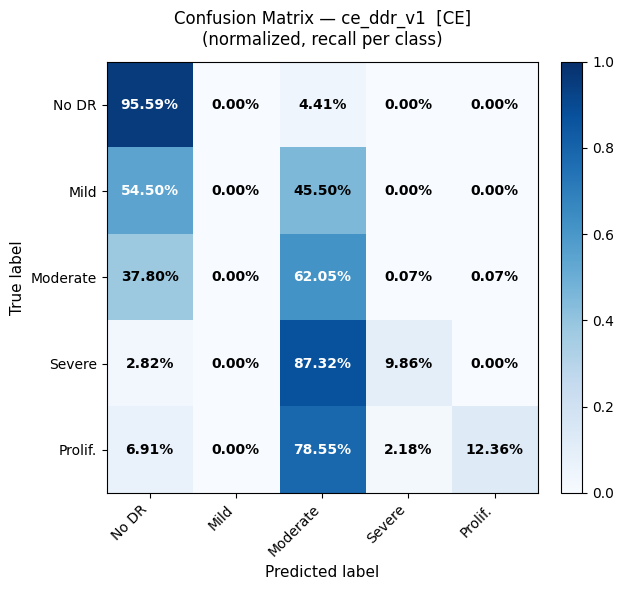


Classification Report
              precision    recall  f1-score   support

       No DR       0.74      0.96      0.83      1880
        Mild       0.00      0.00      0.00       189
    Moderate       0.65      0.62      0.64      1344
      Severe       0.50      0.10      0.16        71
     Prolif.       0.97      0.12      0.22       275

    accuracy                           0.71      3759
   macro avg       0.57      0.36      0.37      3759
weighted avg       0.68      0.71      0.66      3759


CO₂ total CE      : 0.003073 kg
CO₂ par époque CE : 0.003073 kg

── Évaluation test (CE) ──
  Test loss  : 0.8250
  Test kappa : 0.6298  (papier sans bruit ~0.883)
  Test acc   : 0.7108
  Test F1    : 0.3707

Runner QMix
QMixEngine ✓  mode=qmix  run=qmix_ddr_v1
Params total : 55.95 M  (2 réseau(x))
Pas encore entraîné.
  CO₂ époque 1 : 0.009227 kg
Ep 001/1 [QMIX] lr=0.00010 | train loss=1.5534 kappa=0.1096 | val   loss=1.2152 kappa=0.6782

Run : qmix_ddr_v1  [QMIX]
  Best kappa (val

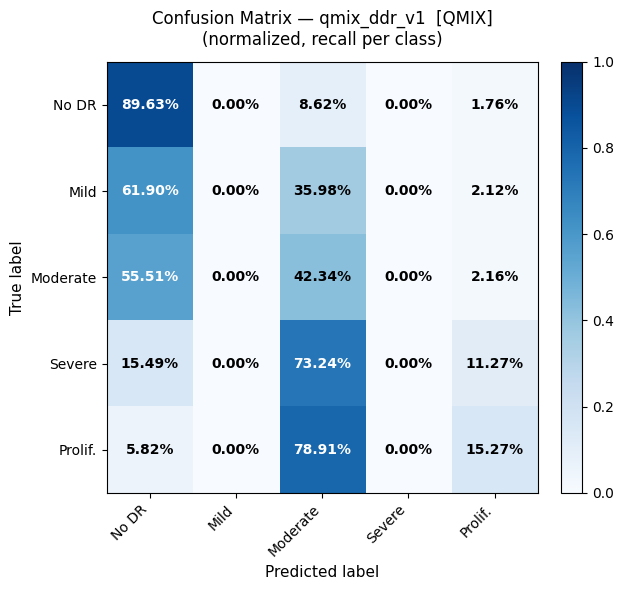


Classification Report
              precision    recall  f1-score   support

       No DR       0.65      0.90      0.76      1880
        Mild       0.00      0.00      0.00       189
    Moderate       0.53      0.42      0.47      1344
      Severe       0.00      0.00      0.00        71
     Prolif.       0.36      0.15      0.21       275

    accuracy                           0.61      3759
   macro avg       0.31      0.29      0.29      3759
weighted avg       0.54      0.61      0.56      3759


CO₂ total QMix      : 0.009227 kg
CO₂ par époque QMix : 0.009227 kg

── Évaluation test (QMix) ──
  Test loss  : 1.2671
  Test kappa : 0.4715  (papier 50H+15L ~0.879)
  Test acc   : 0.6108
  Test F1    : 0.2886

                  Comparaison finale                   
Méthode           Test Kappa   Test Acc    Test F1     CO₂ (kg)
------------------------------------------------------------
Standard CE           0.6298     0.7108     0.3707     0.003073
QMix                  0.4715  

In [14]:
# ============================================================
# STEP 7c — Runner QMix
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

CKPT_DIR_CE   = "/kaggle/working/runs/ce_ddr_v1"
CKPT_DIR_QMIX = "/kaggle/working/runs/qmix_ddr_v1"
os.makedirs(CKPT_DIR_CE,   exist_ok=True)
os.makedirs(CKPT_DIR_QMIX, exist_ok=True)

# ── Standard CE ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("Runner Standard CE")
print("=" * 55)

ce_engine = QMixEngine(
    cfg,
    device   = DEVICE,
    mode     = 'ce',
    run_name = 'ce_ddr_v1',
)
ce_engine.summary()

ce_history = ce_engine.fit(
    train_dataset = ds_ce_train,
    val_loader    = val_loader_ce,
)
ce_engine.summary()

# ── Sauvegardes CE ───────────────────────────────────────────
ce_engine.save(f"{CKPT_DIR_CE}/ce_ddr_v1.pt")
ce_engine.save_weights(f"{CKPT_DIR_CE}/ce_ddr_v1_weights.pt")
ce_engine.save_history(f"{CKPT_DIR_CE}/ce_ddr_v1_history.json")
ce_engine.log_experiment(CKPT_DIR_CE)

# ── Matrice de confusion CE ───────────────────────────────────
cm_ce = ce_engine.plot_confusion_matrix(
    test_loader_ce,
    class_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Prolif.'],
    normalize  = True,
    save_path  = f"{CKPT_DIR_CE}/ce_ddr_v1_confusion_matrix.png",
)

# ── CO₂ CE ───────────────────────────────────────────────────
emissions_ce = [e for e in ce_engine.history.get("emissions", [])
                if e is not None]
if emissions_ce:
    print(f"\nCO₂ total CE      : {sum(emissions_ce):.6f} kg")
    print(f"CO₂ par époque CE : {sum(emissions_ce)/len(emissions_ce):.6f} kg")
else:
    print("\nCO₂ CE : non mesuré (codecarbon indisponible)")

# ── Évaluation test CE ────────────────────────────────────────
print("\n── Évaluation test (CE) ──")
ce_test_loss, ce_test_kappa, ce_test_acc, ce_test_f1 = ce_engine._evaluate(
    ce_engine.nets, test_loader_ce)
print(f"  Test loss  : {ce_test_loss:.4f}")
print(f"  Test kappa : {ce_test_kappa:.4f}  (papier sans bruit ~0.883)")
print(f"  Test acc   : {ce_test_acc:.4f}")
print(f"  Test F1    : {ce_test_f1:.4f}")

# ── QMix ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Runner QMix")
print("=" * 55)

qm_engine = QMixEngine(
    cfg,
    device   = DEVICE,
    mode     = 'qmix',
    run_name = 'qmix_ddr_v1',
)
qm_engine.summary()

qm_history = qm_engine.fit(
    train_dataset = ds_qm_train,
    val_loader    = val_loader_qm,
)
qm_engine.summary()

# ── Sauvegardes QMix ─────────────────────────────────────────
qm_engine.save(f"{CKPT_DIR_QMIX}/qmix_ddr_v1.pt")
qm_engine.save_weights(f"{CKPT_DIR_QMIX}/qmix_ddr_v1_weights.pt")
qm_engine.save_history(f"{CKPT_DIR_QMIX}/qmix_ddr_v1_history.json")
qm_engine.log_experiment(CKPT_DIR_QMIX)

# ── Matrice de confusion QMix ─────────────────────────────────
cm_qm = qm_engine.plot_confusion_matrix(
    test_loader_qm,
    class_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Prolif.'],
    normalize  = True,
    save_path  = f"{CKPT_DIR_QMIX}/qmix_ddr_v1_confusion_matrix.png",
)

# ── CO₂ QMix ─────────────────────────────────────────────────
emissions_qm = [e for e in qm_engine.history.get("emissions", [])
                if e is not None]
if emissions_qm:
    print(f"\nCO₂ total QMix      : {sum(emissions_qm):.6f} kg")
    print(f"CO₂ par époque QMix : {sum(emissions_qm)/len(emissions_qm):.6f} kg")
else:
    print("\nCO₂ QMix : non mesuré (codecarbon indisponible)")

# ── Évaluation test QMix ─────────────────────────────────────
print("\n── Évaluation test (QMix) ──")
qm_test_loss, qm_test_kappa, qm_test_acc, qm_test_f1 = qm_engine._evaluate(
    qm_engine.nets, test_loader_qm)
print(f"  Test loss  : {qm_test_loss:.4f}")
print(f"  Test kappa : {qm_test_kappa:.4f}  (papier 50H+15L ~0.879)")
print(f"  Test acc   : {qm_test_acc:.4f}")
print(f"  Test F1    : {qm_test_f1:.4f}")

# ── Comparaison finale ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Comparaison finale':^55}")
print(f"{'='*55}")
print(f"{'Méthode':<15} {'Test Kappa':>12} {'Test Acc':>10} "
      f"{'Test F1':>10} {'CO₂ (kg)':>12}")
print(f"{'-'*60}")
co2_ce = round(sum(emissions_ce), 6) if emissions_ce else "N/A"
co2_qm = round(sum(emissions_qm), 6) if emissions_qm else "N/A"
print(f"{'Standard CE':<15} {ce_test_kappa:>12.4f} {ce_test_acc:>10.4f} "
      f"{ce_test_f1:>10.4f} {str(co2_ce):>12}")
print(f"{'QMix':<15} {qm_test_kappa:>12.4f} {qm_test_acc:>10.4f} "
      f"{qm_test_f1:>10.4f} {str(co2_qm):>12}")
print(f"{'Δ (QMix-CE)':<15} {qm_test_kappa-ce_test_kappa:>+12.4f} "
      f"{qm_test_acc-ce_test_acc:>+10.4f} {qm_test_f1-ce_test_f1:>+10.4f}")
print(f"{'='*55}")
print(f"\nRésultats CE   → {CKPT_DIR_CE}")
print(f"Résultats QMix → {CKPT_DIR_QMIX}")

In [15]:
# # ── Packages réellement utilisés dans le notebook ────────────
# import pkg_resources, sys

# # Packages présents dans sys.modules après exécution du notebook
# used = {
#     mod.split(".")[0]
#     for mod in sys.modules
#     if not mod.startswith("_")
# }

# installed = {pkg.key: pkg.version for pkg in pkg_resources.working_set}

# print("# requirements.txt — packages actifs dans cette session")
# for name in sorted(used):
#     name_lower = name.lower().replace("_", "-")
#     if name_lower in installed:
#         print(f"{name_lower}=={installed[name_lower]}")